# Tarea 3 (RL)
**Nombre:** Adrián Jesús Maldonado Oclica.



(El colab se puede probar directamente clonando el repositorio que se hizo con todos los desarrollos para la tarea).

## Configuración inicial:

In [ ]:
# Bajar el repo (EN COLAB)
REPO_URL = "https://github.com/Adrian040/DDQN_implementation_and_more.git"

!git clone {REPO_URL}
%cd DDQN_implementation_and_more

In [ ]:
pip -q install -r requirements.txt  # Instalamos las librerías utilizadas, si es necesario.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 7.8 MB/s eta 0:00:00


In [ ]:
# Se agregó la opción de entrenar aprovechando CUDA cuando esté disponible.
import os
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("CUDA disponible:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA disponible: True
GPU: Tesla T4


In [ ]:
import gymnasium as gym

matches = [k for k in gym.registry.keys() if "MinAtar" in k]
print(matches[:20])

[]


In [ ]:
# Se registra porque hubo problemas para encontrarlo.
import gymnasium as gym
from gymnasium.envs.registration import register

register(
    id="MinAtar/Breakout-v1",
    entry_point="minatar.envs.breakout:Env",
)

In [ ]:
from src.common.envs import make_minatar_breakout, make_atari_breakout

env = make_minatar_breakout(seed=0)
obs, info = env.reset()
print("MinAtar obs shape:", obs.shape, "acciones:", env.action_space.n)
env.close()

env = make_atari_breakout(seed=0)
obs, info = env.reset()
print("Atari obs shape:", obs.shape, "acciones:", env.action_space.n)
env.close()

MinAtar obs shape: (4, 10, 10) acciones: 3
Atari obs shape: (4, 84, 84) acciones: 4


## Configuración general:

In [ ]:
SEEDS = [0, 1, 2, 3, 4]

MINATAR_STEPS = 200_000
ATARI_STEPS = 500_000

NES_MINATAR_GENS = 200
GA_MINATAR_GENS = 200

NES_ATARI_GENS = 100
GA_ATARI_GENS = 100

## Test rapido para probar los modelos:

In [ ]:
!python -m src.ddqn.train_ddqn --env minatar --seed 0 --total_steps 10000 --eval_every 5000
!python -m src.ppo.train_ppo --env minatar --seed 0 --total_steps 10000 --eval_every 5000
!python -m src.evolutionary.train_nes_ga --method nes --env minatar --seed 0 --generations 5 --eval_every 1

[minatar] step=     92 | ep=  10 | retorno=   0.00 | avg20=   0.30 | eps=0.999 | loss=     nan
[minatar] step=    172 | ep=  20 | retorno=   1.00 | avg20=   0.25 | eps=0.998 | loss=     nan
[minatar] step=    262 | ep=  30 | retorno=   1.00 | avg20=   0.25 | eps=0.998 | loss=     nan
[minatar] step=    392 | ep=  40 | retorno=   1.00 | avg20=   0.50 | eps=0.996 | loss=     nan
[minatar] step=    482 | ep=  50 | retorno=   1.00 | avg20=   0.50 | eps=0.995 | loss=     nan
[minatar] step=    584 | ep=  60 | retorno=   1.00 | avg20=   0.35 | eps=0.994 | loss=     nan
[minatar] step=    674 | ep=  70 | retorno=   0.00 | avg20=   0.35 | eps=0.994 | loss=     nan
[minatar] step=    774 | ep=  80 | retorno=   2.00 | avg20=   0.35 | eps=0.993 | loss=     nan
[minatar] step=    854 | ep=  90 | retorno=   0.00 | avg20=   0.30 | eps=0.992 | loss=     nan
[minatar] step=    956 | ep= 100 | retorno=   0.00 | avg20=   0.30 | eps=0.991 | loss=     nan
[minatar] step=   1076 | ep= 110 | retorno=   0.00

------
# DDQN:

### DDQN propio en MinAtar

In [ ]:
for seed in SEEDS:
    !python -m src.ddqn.train_ddqn --env minatar --seed {seed} --total_steps {MINATAR_STEPS}

[minatar] step=     92 | ep=  10 | retorno=   0.00 | avg20=   0.30 | eps=0.999 | loss=     nan
[minatar] step=    172 | ep=  20 | retorno=   1.00 | avg20=   0.25 | eps=0.998 | loss=     nan
[minatar] step=    262 | ep=  30 | retorno=   1.00 | avg20=   0.25 | eps=0.998 | loss=     nan
[minatar] step=    392 | ep=  40 | retorno=   1.00 | avg20=   0.50 | eps=0.996 | loss=     nan
[minatar] step=    482 | ep=  50 | retorno=   1.00 | avg20=   0.50 | eps=0.995 | loss=     nan
[minatar] step=    584 | ep=  60 | retorno=   1.00 | avg20=   0.35 | eps=0.994 | loss=     nan
[minatar] step=    674 | ep=  70 | retorno=   0.00 | avg20=   0.35 | eps=0.994 | loss=     nan
[minatar] step=    774 | ep=  80 | retorno=   2.00 | avg20=   0.35 | eps=0.993 | loss=     nan
[minatar] step=    854 | ep=  90 | retorno=   0.00 | avg20=   0.30 | eps=0.992 | loss=     nan
[minatar] step=    956 | ep= 100 | retorno=   0.00 | avg20=   0.30 | eps=0.991 | loss=     nan
[minatar] step=   1076 | ep= 110 | retorno=   0.00

### DQN* oficial SB3 en MinAtar:

*Dado que la documentación oficial de Stable-Baselines3 no incluye una implementación explícita de Double DQN (DDQN), se optó por comparar la implementación propia de DDQN con el algoritmo DQN vanilla disponible en dicha librería. Si bien en versiones anteriores existía la posibilidad de activar DDQN mediante el parámetro ddqn=True, estas versiones no se encuentran actualizadas y pueden presentar incompatibilidades con librerías actuales. Por esta razón, se decidió utilizar la versión estable y mantenida de DQN como referencia para la comparación.

In [ ]:
for seed in SEEDS:
    !python -m src.ddqn.train_sb3_dqn --env minatar --seed {seed} --total_steps {MINATAR_STEPS}

Se truncaron las últimas líneas 5000 del resultado de transmisión.
|    n_updates        | 31207    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 48.7     |
|    ep_rew_mean      | 3.98     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 6940     |
|    fps              | 543      |
|    time_elapsed     | 248      |
|    total_timesteps  | 135060   |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.116    |
|    n_updates        | 31264    |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 49.1     |
|    ep_rew_mean      | 4.02     |
|    exploration_rate | 0.05     |
| time/               |          |
|    episodes         | 6944     |
|    fps              | 543      |
|    time_elapsed     | 249      |
|    total_timesteps  |

### Graficar DDQN vs SB3:

In [ ]:
!python -m src.ddqn.plot_ddqn_vs_sb3 \
  --ours_pattern "results/ddqn_minatar_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_dqn_minatar_seed*/evaluations.npz" \
  --title "DDQN propio vs DQN oficial SB3 en MinAtar Breakout" \
  --save_path "ddqn_vs_sb3_minatar.png"

Gráfica guardada en: ddqn_vs_sb3_minatar.png


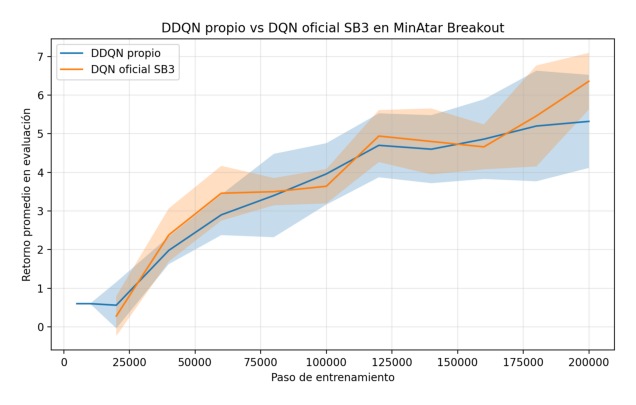

In [ ]:
# Mostramos la figura:
img = plt.imread("ddqn_vs_sb3_minatar.png")
plt.figure(figsize=(9,5))
plt.imshow(img)
plt.axis("off")
plt.show()

### Obtenemos estadística descriptiva y prueba de Wilcoxon rank para DDQN vs SB3

In [ ]:
!python -m src.ddqn.pairwise_stats_ddqn_vs_sb3 \
  --ours_pattern "results/ddqn_minatar_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_dqn_minatar_seed*/evaluations.npz"


=== Estadística descriptiva ===
         método  n    media      std  mediana  mín  máx
    DDQN propio  6 4.533333 2.207865      4.5  0.6  7.0
DQN oficial SB3  5 6.360000 0.733485      6.5  5.4  7.3

=== Wilcoxon rank-sum ===
estadístico = -1.643168
p-valor     = 0.100348
Conclusión: no se detectó diferencia estadísticamente significativa (alpha = 0.05).


-----------------
Git backup:

In [ ]:
# !git status
# !git stash
# !git pull
# !git stash pop
# !git add .
# !git status
# !git commit -m "RunDDQN: Sube los resultados obtenidos para la sección de DDQN."
# !git push

------------
# PPO
### PPO propio en MinAtar:

In [ ]:
for seed in SEEDS:
    !python -m src.ppo.train_ppo --env minatar --seed {seed} --total_steps {MINATAR_STEPS}

[minatar] step=   2048 | upd=   1 | avg20=   0.20 | pi_loss=-0.0052 | v_loss=0.2008
[minatar] step=   4096 | upd=   2 | avg20=   0.50 | pi_loss=-0.0005 | v_loss=0.2521
[minatar] step=   6144 | upd=   3 | avg20=   0.55 | pi_loss=-0.0018 | v_loss=0.2433
[minatar] step=   8192 | upd=   4 | avg20=   0.45 | pi_loss=-0.0042 | v_loss=0.2436
[minatar] step=  10240 | upd=   5 | avg20=   0.65 | pi_loss=-0.0028 | v_loss=0.2159
[minatar] step=  12288 | upd=   6 | avg20=   0.40 | pi_loss=-0.0054 | v_loss=0.2097
[minatar] step=  14336 | upd=   7 | avg20=   0.25 | pi_loss=-0.0093 | v_loss=0.2072
[minatar] step=  16384 | upd=   8 | avg20=   0.50 | pi_loss=-0.0061 | v_loss=0.2623
[minatar] step=  18432 | upd=   9 | avg20=   0.65 | pi_loss=-0.0070 | v_loss=0.2655
[minatar] step=  20480 | upd=  10 | avg20=   0.65 | pi_loss=-0.0042 | v_loss=0.3037
[EVAL] env=minatar | step=20480 | mean_return=0.600 | std_return=0.490
[minatar] step=  22528 | upd=  11 | avg20=   0.80 | pi_loss=-0.0050 | v_loss=0.2941
[mina

### PPO oficial SB3 en MinAtar:

In [ ]:
for seed in SEEDS:
    !python -m src.ppo.train_sb3_ppo --env minatar --seed {seed} --total_steps {MINATAR_STEPS}

Se truncaron las últimas líneas 5000 del resultado de transmisión.
|    time_elapsed         | 309         |
|    total_timesteps      | 139264      |
| train/                  |             |
|    approx_kl            | 0.012038755 |
|    clip_fraction        | 0.0701      |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.251      |
|    explained_variance   | 0.911       |
|    learning_rate        | 0.00025     |
|    loss                 | 0.0553      |
|    n_updates            | 268         |
|    policy_gradient_loss | -0.00533    |
|    value_loss           | 0.146       |
-----------------------------------------
Eval num_timesteps=140000, episode_reward=4.20 +/- 2.14
Episode length: 51.60 +/- 23.66
-----------------------------------------
| eval/                   |             |
|    mean_ep_length       | 51.6        |
|    mean_reward          | 4.2         |
| time/                   |             |
|    total_timesteps      | 140000      |
| tra

### Grafica PPO vs SB3

In [ ]:
!python -m src.ppo.plot_ppo_vs_sb3 \
  --ours_pattern "results/ppo_minatar_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_ppo_minatar_seed*/evaluations.npz" \
  --title "PPO propio vs PPO oficial SB3 en MinAtar Breakout" \
  --save_path "ppo_vs_sb3_minatar.png"

Gráfica guardada en: ppo_vs_sb3_minatar.png


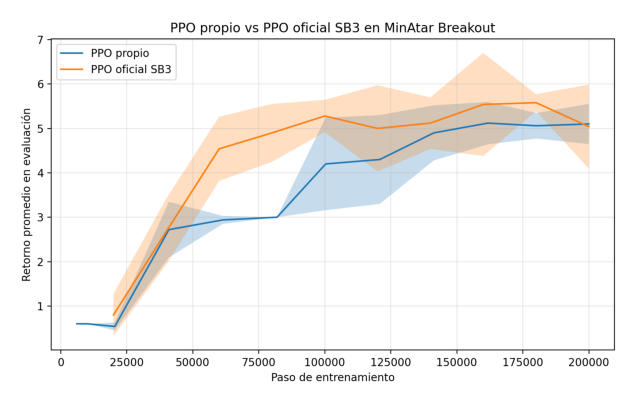

In [ ]:
# Mostramos la figura:
img = plt.imread("ppo_vs_sb3_minatar.png")
plt.figure(figsize=(9,5))
plt.imshow(img)
plt.axis("off")
plt.show()

### Obtenemos estadística descriptiva y prueba de Wilcoxon rank para PPO y SB3:

In [ ]:
!python -m src.ppo.pairwise_stats_ppo_vs_sb3 \
  --ours_pattern "results/ppo_minatar_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_ppo_minatar_seed*/evaluations.npz"


=== Estadística descriptiva ===
         método  n  media      std  mediana  mín  máx
     PPO propio  6   4.35 1.881223     5.05  0.6  5.5
PPO oficial SB3  5   5.04 0.944987     5.00  3.8  6.4

=== Wilcoxon rank-sum ===
estadístico = -0.091287
p-valor     = 0.927264
Conclusión: no se detectó diferencia estadísticamente significativa (alpha = 0.05).


-----------------
Git backup:

In [ ]:
# !git status
# !git stash
# !git pull
# !git stash pop
# !git add .
# !git status
# !git commit -m "PPOrun: Se guardan los resultados de la sección de PPO"
# !git push

---------------
# NES / GA
### NES en MinAtar:

In [ ]:
for seed in SEEDS:
    !python -m src.evolutionary.train_nes_ga --method nes --env minatar --seed {seed} --generations {NES_MINATAR_GENS}

[NES][minatar] gen=   1 | mean_fit=  0.500 | best_fit=  2.000
[NES][minatar] gen=   2 | mean_fit=  0.333 | best_fit=  3.000
[NES][minatar] gen=   3 | mean_fit=  0.433 | best_fit=  2.000
[NES][minatar] gen=   4 | mean_fit=  0.433 | best_fit=  3.000
[NES][minatar] gen=   5 | mean_fit=  0.467 | best_fit=  1.000
[NES][minatar] gen=   6 | mean_fit=  0.167 | best_fit=  1.000
[NES][minatar] gen=   7 | mean_fit=  0.433 | best_fit=  2.000
[NES][minatar] gen=   8 | mean_fit=  0.367 | best_fit=  1.000
[NES][minatar] gen=   9 | mean_fit=  0.467 | best_fit=  4.000
[NES][minatar] gen=  10 | mean_fit=  0.233 | best_fit=  2.000
[EVAL] method=nes | env=minatar | gen=10 | mean_return=0.600 | std_return=0.490
[NES][minatar] gen=  11 | mean_fit=  0.367 | best_fit=  2.000
[NES][minatar] gen=  12 | mean_fit=  0.300 | best_fit=  2.000
[NES][minatar] gen=  13 | mean_fit=  0.167 | best_fit=  1.000
[NES][minatar] gen=  14 | mean_fit=  0.067 | best_fit=  1.000
[NES][minatar] gen=  15 | mean_fit=  0.400 | best_fi

### GA en MinAtar:

In [ ]:
for seed in SEEDS:
    !python -m src.evolutionary.train_nes_ga --method ga --env minatar --seed {seed} --generations {GA_MINATAR_GENS}

[GA][minatar] gen=   1 | mean_fit=  0.533 | best_fit=  2.000
[GA][minatar] gen=   2 | mean_fit=  0.300 | best_fit=  2.000
[GA][minatar] gen=   3 | mean_fit=  0.500 | best_fit=  2.000
[GA][minatar] gen=   4 | mean_fit=  0.400 | best_fit=  3.000
[GA][minatar] gen=   5 | mean_fit=  0.333 | best_fit=  2.000
[GA][minatar] gen=   6 | mean_fit=  0.300 | best_fit=  1.000
[GA][minatar] gen=   7 | mean_fit=  0.467 | best_fit=  3.000
[GA][minatar] gen=   8 | mean_fit=  0.200 | best_fit=  2.000
[GA][minatar] gen=   9 | mean_fit=  0.567 | best_fit=  2.000
[GA][minatar] gen=  10 | mean_fit=  0.333 | best_fit=  2.000
[EVAL] method=ga | env=minatar | gen=10 | mean_return=0.600 | std_return=0.490
[GA][minatar] gen=  11 | mean_fit=  0.667 | best_fit=  3.000
[GA][minatar] gen=  12 | mean_fit=  0.567 | best_fit=  2.000
[GA][minatar] gen=  13 | mean_fit=  0.600 | best_fit=  3.000
[GA][minatar] gen=  14 | mean_fit=  0.300 | best_fit=  2.000
[GA][minatar] gen=  15 | mean_fit=  0.467 | best_fit=  3.000
[GA][m

### Graficar NES:

In [ ]:
!python -m src.evolutionary.plot_nes_ga_learning_curves \
  --pattern "results/nes_minatar_seed*/eval_log.csv" \
  --title "NES en MinAtar Breakout" \
  --save_path "nes_minatar_curve.png"

Gráfica guardada en: nes_minatar_curve.png


### Graficar GA:

In [ ]:
!python -m src.evolutionary.plot_nes_ga_learning_curves \
  --pattern "results/ga_minatar_seed*/eval_log.csv" \
  --title "GA en MinAtar Breakout" \
  --save_path "ga_minatar_curve.png"

Gráfica guardada en: ga_minatar_curve.png


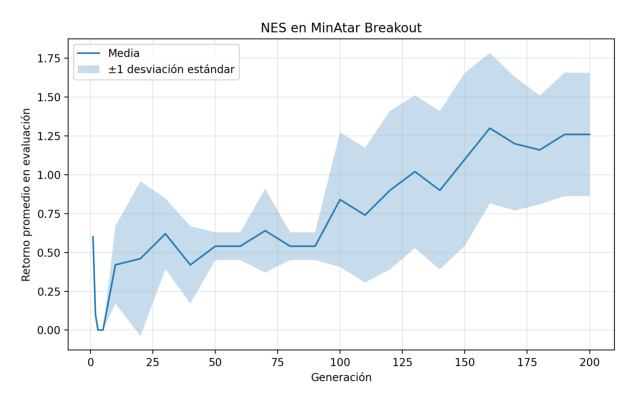

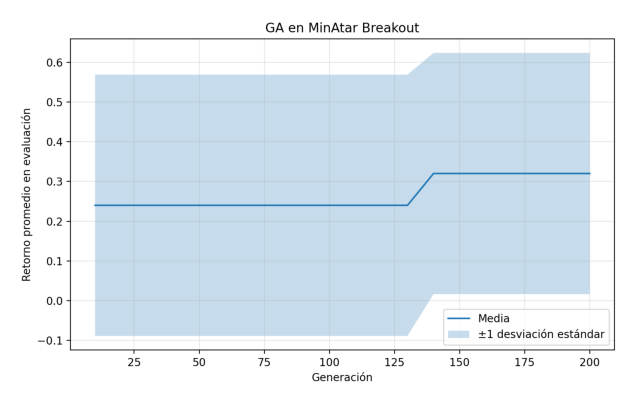

In [ ]:
# mostramos las figuras:
for path in ["nes_minatar_curve.png", "ga_minatar_curve.png"]:
    img = plt.imread(path)
    plt.figure(figsize=(9,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

In [ ]:
#!python -m src.evolutionary.plot_nes_vs_ga \
#  --nes_pattern "results/nes_minatar_seed*/eval_log.csv" \
#  --ga_pattern  "results/ga_minatar_seed*/eval_log.csv" \
#  --title "NES vs GA en MinAtar Breakout" \
#  --save_path "compare_minatar_nes_vs_ga.png"

Gráfica guardada en: compare_minatar_nes_vs_ga.png


## Estadísticas entre las implementaciones de NES y GA:

In [ ]:
!python -m src.evolutionary.pairwise_stats_nes_vs_ga \
  --nes_pattern "results/nes_minatar_seed*/eval_log.csv" \
  --ga_pattern  "results/ga_minatar_seed*/eval_log.csv"


=== Estadística descriptiva ===
método  n  media      std  mediana  mín  máx
   NES  7   0.90 0.695222      1.2  0.0  1.6
    GA  5   0.32 0.303315      0.4  0.0  0.6

=== Wilcoxon rank-sum ===
estadístico = 1.380397
p-valor     = 0.167465
Conclusión: no se detectó diferencia estadísticamente significativa (alpha = 0.05).


-----------------
Git backup:

In [ ]:
!git status
!git stash
!git pull
!git stash pop
!git add .
!git status
!git commit -m "NESGArun: Se guardan los resultados de la sección de NES/GA en MinAtar"
!git push

------------
# Atari
### DDQN y PPO en Atari:

In [ ]:
# Se baja un poco la cantidad de semillas, los steps y el intervalor de evaluación debido al tiempo de ejecución
SEEDS = [0,1,2]
ATARI_STEPS = 200_000

In [ ]:
for seed in SEEDS:
    !python -m src.ddqn.train_ddqn --env atari --seed {seed} --total_steps {ATARI_STEPS} --eval_every 50000 --eval_episodes 3

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
[atari] step=   1776 | ep=  10 | retorno=   2.00 | avg20=   1.20 | eps=0.983 | loss=     nan
[atari] step=   3739 | ep=  20 | retorno=   2.00 | avg20=   1.30 | eps=0.964 | loss=     nan
[atari] step=   5835 | ep=  30 | retorno=   2.00 | avg20=   1.70 | eps=0.945 | loss=     nan
[atari] step=   7493 | ep=  40 | retorno=   1.00 | avg20=   1.35 | eps=0.929 | loss=     nan
[atari] step=   9392 | ep=  50 | retorno=   1.00 | avg20=   1.00 | eps=0.911 | loss=     nan
[atari] step=  11608 | ep=  60 | retorno=   0.00 | avg20=   1.65 | eps=0.890 | loss=  0.0000
[atari] step=  13557 | ep=  70 | retorno=   2.00 | avg20=   1.75 | eps=0.871 | loss=  0.0078
[atari] step=  15273 | ep=  80 | retorno=   0.00 | avg20=   1.30 | eps=0.855 | loss=  0.0000
[atari] step=  17185 | ep=  90 | retorno=   1.00 | avg20=   1.20 | eps=0.837 | loss=  0.0077
[atari] step=  19110 | ep= 100 | retorno=   2.00 | avg20=   1.30 | eps=0.818 | loss

In [ ]:
# ## Git backup:
# !git status
# !git stash
# !git pull
# !git stash pop
# !git add .
# !git status
# !git commit -m "DDQNrun: Se guardan los resultados de la sección de DDQN en Atari"
# !git push

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	results/ddqn_atari_seed0_1774694118/
	results/ddqn_atari_seed1_1774695182/
	results/ddqn_atari_seed2_1774696031/

nothing added to commit but untracked files present (use "git add" to track)
No local changes to save
Already up to date.
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   results/ddqn_minatar_seed0_1774693414/eval_log.csv
	new file:   results/ddqn_minatar_seed0_1774693414/model_final.pt
	new file:   results/ddqn_minatar_seed0_1774693414/train_log.csv
	new file:   results/nes_minatar_seed0_1774693450/best_model.pt
	new file:   results/nes_minatar_seed0_1774693450/eval_log.csv
	new file:   results/nes_minatar_seed0_1774693450/train_log.csv
	new file:   results/ppo_minatar_seed0_1774693427/eval_log.csv
	new file:   results/ppo_minata

In [ ]:
for seed in SEEDS:
    !python -m src.ddqn.train_sb3_dqn --env atari --seed {seed} --total_steps {ATARI_STEPS} --eval_every 50000 --eval_episodes 3


Se truncaron las últimas líneas 5000 del resultado de transmisión.
|    ep_rew_mean      | 1.31     |
|    exploration_rate | 0.72     |
| time/               |          |
|    episodes         | 156      |
|    fps              | 331      |
|    time_elapsed     | 88       |
|    total_timesteps  | 29447    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.000336 |
|    n_updates        | 4861     |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 190      |
|    ep_rew_mean      | 1.34     |
|    exploration_rate | 0.713    |
| time/               |          |
|    episodes         | 160      |
|    fps              | 328      |
|    time_elapsed     | 92       |
|    total_timesteps  | 30247    |
| train/              |          |
|    learning_rate    | 0.0001   |
|    loss             | 0.00272  |
|    n_updates        | 5061     |
-----------------------

Gráfica guardada en: ddqn_vs_sb3_atari.png


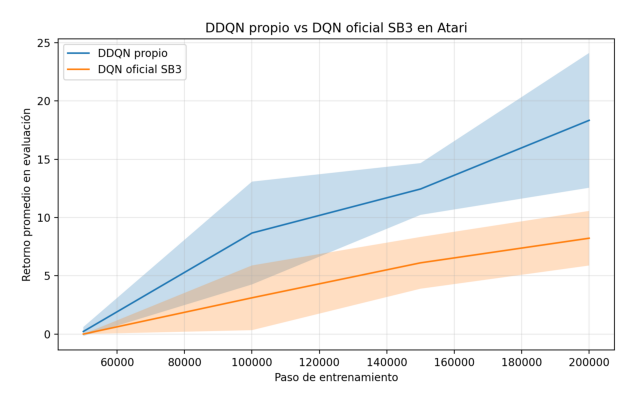

In [ ]:
# Gráficas de comparación:
!python -m src.ddqn.plot_ddqn_vs_sb3 \
  --ours_pattern "results/ddqn_atari_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_dqn_atari_seed*/evaluations.npz" \
  --title "DDQN propio vs DQN oficial SB3 en Atari" \
  --save_path "ddqn_vs_sb3_atari.png"
# Mostramos la figura:
img = plt.imread("ddqn_vs_sb3_atari.png")
plt.figure(figsize=(9,5))
plt.imshow(img)
plt.axis("off")
plt.show()

En la comparación se observa que el modelo propio de DDQN alcanza un rendimiento promedio de evaluación claramente superior al del DQN oficial de SB3 a lo largo de todo el entrenamiento. Desde etapas tempranas ambos métodos muestran mejora, pero conforme avanzan los pasos de entrenamiento la diferencia se vuelve más marcada a favor de DDQN, que termina con un retorno promedio considerablemente mayor. Esto sugiere que, en este entorno más complejo, la corrección de sobreestimación incorporada en DDQN le permitió aprender una política más efectiva que la obtenida con DQN estándar.

En contraste, en la comparación análoga sobre MinAtar anteriormente, en donde los resultados entre ambos métodos fueron bastante más parecidos. De aquí sepuede interpretar que, en un entorno más simple y compacto (MinAtar), las ventajas de DDQN frente a DQN no se manifiestan de manera tan fuerte como en Atari, donde la dificultad del problema y la mayor complejidad dinámica hacen más evidente el beneficio de reducir la sobreestimación de valores Q.

## Estadísticas DDQN y DQN sb3:

In [ ]:
!python -m src.ddqn.pairwise_stats_ddqn_vs_sb3 \
  --ours_pattern "results/ddqn_atari_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_dqn_atari_seed*/evaluations.npz"


=== Estadística descriptiva ===
         método  n     media      std  mediana       mín       máx
    DDQN propio  3 18.333333 5.783117     17.0 13.333333 24.666667
DQN oficial SB3  3  8.222222 2.341256      8.0  6.000000 10.666667

=== Wilcoxon rank-sum ===
estadístico = 1.963961
p-valor     = 0.049535
Conclusión: existe diferencia estadísticamente significativa (alpha = 0.05).


In [ ]:
## Git backup:
!git status
!git stash
!git pull
!git stash pop
!git add .
!git status
!git commit -m "DDQNrun: Se guardan los resultados de la sección de DDQN_sb3 en Atari"
!git push

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	results/sb3_dqn_atari_seed0_1774697026/
	results/sb3_dqn_atari_seed1_1774698398/
	results/sb3_dqn_atari_seed2_1774699732/

nothing added to commit but untracked files present (use "git add" to track)
No local changes to save
Already up to date.
No stash entries found.
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   results/sb3_dqn_atari_seed0_1774697026/best_model.zip
	new file:   results/sb3_dqn_atari_seed0_1774697026/config.json
	new file:   results/sb3_dqn_atari_seed0_1774697026/evaluations.npz
	new file:   results/sb3_dqn_atari_seed0_1774697026/model_final.zip
	new file:   results/sb3_dqn_atari_seed0_1774697026/train_monitor.csv
	new file:   results/sb3_dqn_atari_seed1_1774698398/best_model.zip
	new file:   results/sb3_dqn_atari_seed1_17

In [ ]:
for seed in SEEDS:
    !python -m src.ppo.train_ppo --env atari --seed {seed} --total_steps {ATARI_STEPS} --eval_every 50000 --eval_episodes 3

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
[atari] step=   2048 | upd=   1 | avg20=   0.82 | pi_loss=0.0003 | v_loss=0.0437
[atari] step=   4096 | upd=   2 | avg20=   1.35 | pi_loss=-0.0002 | v_loss=0.0536
[atari] step=   6144 | upd=   3 | avg20=   1.50 | pi_loss=-0.0029 | v_loss=0.0665
[atari] step=   8192 | upd=   4 | avg20=   1.60 | pi_loss=-0.0011 | v_loss=0.0665
[atari] step=  10240 | upd=   5 | avg20=   1.35 | pi_loss=-0.0027 | v_loss=0.0500
[atari] step=  12288 | upd=   6 | avg20=   1.00 | pi_loss=-0.0010 | v_loss=0.0517
[atari] step=  14336 | upd=   7 | avg20=   1.50 | pi_loss=-0.0039 | v_loss=0.0637
[atari] step=  16384 | upd=   8 | avg20=   1.45 | pi_loss=-0.0009 | v_loss=0.0492
[atari] step=  18432 | upd=   9 | avg20=   1.40 | pi_loss=-0.0003 | v_loss=0.0614
[atari] step=  20480 | upd=  10 | avg20=   1.45 | pi_loss=-0.0057 | v_loss=0.0483
[atari] step=  22528 | upd=  11 | avg20=   0.65 | pi_loss=-0.0028 | v_loss=0.0253
[atari] step=  2457

In [ ]:
# ## Git backup:
# !git status
# !git stash
# !git pull
# !git stash pop
# !git add .
# !git status
# !git commit -m "PPOrun: Se guardan los resultados de la sección de PPO en Atari"
# !git push

On branch main
Your branch is up to date with 'origin/main'.

Untracked files:
  (use "git add <file>..." to include in what will be committed)
	results/ppo_atari_seed0_1774700931/
	results/ppo_atari_seed1_1774701904/
	results/ppo_atari_seed2_1774702596/

nothing added to commit but untracked files present (use "git add" to track)
No local changes to save
Already up to date.
No stash entries found.
On branch main
Your branch is up to date with 'origin/main'.

Changes to be committed:
  (use "git restore --staged <file>..." to unstage)
	new file:   results/ppo_atari_seed0_1774700931/eval_log.csv
	new file:   results/ppo_atari_seed0_1774700931/model_final.pt
	new file:   results/ppo_atari_seed0_1774700931/train_log.csv
	new file:   results/ppo_atari_seed1_1774701904/eval_log.csv
	new file:   results/ppo_atari_seed1_1774701904/model_final.pt
	new file:   results/ppo_atari_seed1_1774701904/train_log.csv
	new file:   results/ppo_atari_seed2_1774702596/eval_log.csv
	new file:   results/ppo_a

In [ ]:
for seed in SEEDS:
    !python -m src.ppo.train_sb3_ppo --env atari --seed {seed} --total_steps {ATARI_STEPS} --eval_every 50000 --eval_episodes 3

Se truncaron las últimas líneas 5000 del resultado de transmisión.
|    ep_rew_mean          | 4.49        |
| time/                   |             |
|    fps                  | 170         |
|    iterations           | 62          |
|    time_elapsed         | 746         |
|    total_timesteps      | 126976      |
| train/                  |             |
|    approx_kl            | 0.013070473 |
|    clip_fraction        | 0.105       |
|    clip_range           | 0.2         |
|    entropy_loss         | -0.946      |
|    explained_variance   | 0.828       |
|    learning_rate        | 0.00025     |
|    loss                 | -0.0307     |
|    n_updates            | 244         |
|    policy_gradient_loss | -0.0139     |
|    value_loss           | 0.0304      |
-----------------------------------------
------------------------------------------
| rollout/                |              |
|    ep_len_mean          | 304          |
|    ep_rew_mean          | 4.68         |
| tim

Gráfica guardada en: ppo_vs_sb3_atari.png


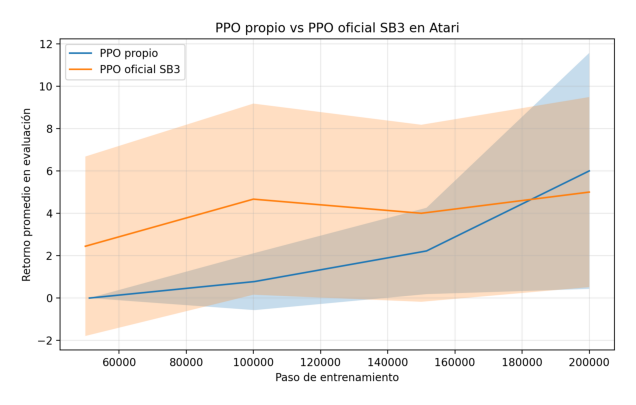

In [ ]:
# Gráficas de comparación:
!python -m src.ppo.plot_ppo_vs_sb3 \
  --ours_pattern "results/ppo_atari_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_ppo_atari_seed*/evaluations.npz" \
  --title "PPO propio vs PPO oficial SB3 en Atari" \
  --save_path "ppo_vs_sb3_atari.png"
# Mostramos la figura:
img = plt.imread("ppo_vs_sb3_atari.png")
plt.figure(figsize=(9,5))
plt.imshow(img)
plt.axis("off")
plt.show()

Acá se observa como el PPO oficial comeinza con un mejor retorno promedio al inicio, pero conforme aumentan los pasos el PPO propio lo alcanza al final en los últimos pasos, sin embargo no se pudo seguir por más tiempo debido al tiempo de entrenamiento.

## Estadísticas PPO y PPO SB3:

In [ ]:
!python -m src.ppo.pairwise_stats_ppo_vs_sb3 \
  --ours_pattern "results/ppo_atari_seed*/eval_log.csv" \
  --sb3_pattern "results/sb3_ppo_atari_seed*/evaluations.npz"


=== Estadística descriptiva ===
         método  n  media      std  mediana  mín       máx
     PPO propio  3    6.0 5.567764 7.000000  0.0 11.000000
PPO oficial SB3  3    5.0 4.484541 6.333333  0.0  8.666667

=== Wilcoxon rank-sum ===
estadístico = 0.436436
p-valor     = 0.662521
Conclusión: no se detectó diferencia estadísticamente significativa (alpha = 0.05).


------
Git backup:

In [ ]:
!git status
!git stash
!git pull
!git stash pop
!git add .
!git status
!git commit -m "PPOrun: Se guardan los resultados de la sección de PPO_sb3 en Atari"
!git push

### NES y GA en Atari:

In [ ]:
# Se bajan las generaciónes y el tamaño de población debido al tiempo grande de ejecución
NES_ATARI_GENS = 20
GA_ATARI_GENS = 20

In [ ]:
for seed in SEEDS:
    !python -m src.evolutionary.train_nes_ga --method nes --env atari --seed {seed} --generations {NES_ATARI_GENS} --population_size 20 --eval_episodes 3

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
[NES][atari] gen=   1 | mean_fit=  0.650 | best_fit=  2.000
[NES][atari] gen=   2 | mean_fit=  1.050 | best_fit=  3.000
[NES][atari] gen=   3 | mean_fit=  1.200 | best_fit=  6.000
[NES][atari] gen=   4 | mean_fit=  0.850 | best_fit=  3.000
[NES][atari] gen=   5 | mean_fit=  1.050 | best_fit=  4.000
[NES][atari] gen=   6 | mean_fit=  1.250 | best_fit=  5.000
[NES][atari] gen=   7 | mean_fit=  1.650 | best_fit=  9.000
[NES][atari] gen=   8 | mean_fit=  1.700 | best_fit=  6.000
[NES][atari] gen=   9 | mean_fit=  1.050 | best_fit=  3.000
[NES][atari] gen=  10 | mean_fit=  1.600 | best_fit=  8.000
[EVAL] method=nes | env=atari | gen=10 | mean_return=0.000 | std_return=0.000
[NES][atari] gen=  11 | mean_fit=  1.850 | best_fit=  6.000
[NES][atari] gen=  12 | mean_fit=  1.900 | best_fit=  9.000
[NES][atari] gen=  13 | mean_fit=  2.250 | best_fit=  9.000
[NES][atari] gen=  14 | mean_fit=  0.750 | best_fit=  3.000
[N

----
Git backup:

In [ ]:
!git status
!git stash
!git pull
!git stash pop
!git add .
!git status
!git commit -m "NESrun: Se guardan los resultados de la sección de NES en Atari"
!git push

In [ ]:
for seed in SEEDS:
    !python -m src.evolutionary.train_nes_ga --method ga --env atari --seed {seed} --generations {GA_ATARI_GENS} --population_size 20 --eval_episodes 3

A.L.E: Arcade Learning Environment (version 0.11.2+ecc1138)
[Powered by Stella]
[GA][atari] gen=   1 | mean_fit=  1.500 | best_fit=  5.000
[GA][atari] gen=   2 | mean_fit=  0.900 | best_fit=  3.000
[GA][atari] gen=   3 | mean_fit=  1.200 | best_fit=  3.000
[GA][atari] gen=   4 | mean_fit=  0.900 | best_fit=  3.000
[GA][atari] gen=   5 | mean_fit=  0.800 | best_fit=  3.000
[GA][atari] gen=   6 | mean_fit=  1.050 | best_fit=  3.000
[GA][atari] gen=   7 | mean_fit=  0.800 | best_fit=  3.000
[GA][atari] gen=   8 | mean_fit=  1.600 | best_fit=  4.000
[GA][atari] gen=   9 | mean_fit=  1.250 | best_fit=  4.000
[GA][atari] gen=  10 | mean_fit=  1.800 | best_fit=  5.000
[EVAL] method=ga | env=atari | gen=10 | mean_return=0.000 | std_return=0.000
[GA][atari] gen=  11 | mean_fit=  1.400 | best_fit=  4.000
[GA][atari] gen=  12 | mean_fit=  0.650 | best_fit=  3.000
[GA][atari] gen=  13 | mean_fit=  1.350 | best_fit=  4.000
[GA][atari] gen=  14 | mean_fit=  0.800 | best_fit=  3.000
[GA][atari] gen= 

----
Git backup:

In [ ]:
# !git status
# !git stash
# !git pull
# !git stash pop
# !git add .
# !git status
# !git commit -m "GArun: Se guardan los resultados de la sección de GA en Atari"
# !git push

Gráfica guardada en: nes_atari_curve.png
Gráfica guardada en: ga_atari_curve.png


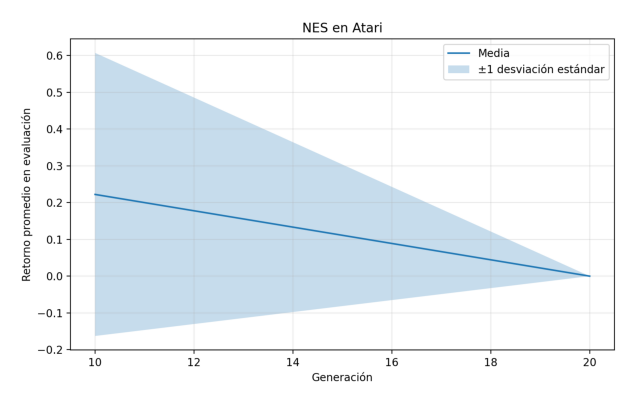

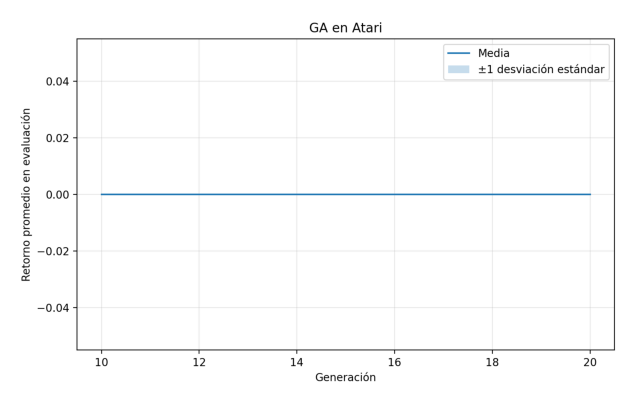

In [ ]:
# Gráficas:
!python -m src.evolutionary.plot_nes_ga_learning_curves \
  --pattern "results/nes_atari_seed*/eval_log.csv" \
  --title "NES en Atari" \
  --save_path "nes_atari_curve.png"
!python -m src.evolutionary.plot_nes_ga_learning_curves \
  --pattern "results/ga_atari_seed*/eval_log.csv" \
  --title "GA en Atari" \
  --save_path "ga_atari_curve.png"
# mostramos las figuras:
for path in ["nes_atari_curve.png", "ga_atari_curve.png"]:
    img = plt.imread(path)
    plt.figure(figsize=(9,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()

En donde ni NES ni GA lograron mostrar una mejora clara en el rendimiento dentro del ajuste al entorno computacional utilizado.

En NES se observa un retorno promedio de evaluación muy cercano a cero e incluso con una ligera tendencia descendente conforme avanzan las generaciones, además de una dispersión relativamente amplia al inicio, lo que sugiere alta variabilidad entre corridas y ausencia de convergencia estable. Por su parte, GA se mantuvo prácticamente en un retorno promedio nulo durante todas las generaciones evaluadas, indicando que, bajo esta configuración, no consiguió encontrar políticas que produjeran un desempeño mejor al inicial.

Estos resultados sugieren que, para un entorno tan demandante como Atari, los ajustes de adaptación al computacional usado para NES y GA fue probablemente insuficiente, o bien que estos métodos requieren un ajuste más fino de hiperparámetros y/o un mayor número de generaciones para mostrar avances significativos

In [ ]:
# Gráfica conjunta
# !python -m src.evolutionary.plot_nes_vs_ga \
#   --nes_pattern "results/nes_atari_seed*/eval_log.csv" \
#   --ga_pattern  "results/ga_atari_seed*/eval_log.csv" \
#   --title "NES vs GA en Atari Breakout" \
#   --save_path "compare_atari_nes_vs_ga.png"

Gráfica guardada en: compare_atari_nes_vs_ga.png


## Estadísticas entre NES y GA en Atari:

In [ ]:
!python -m src.evolutionary.pairwise_stats_nes_vs_ga \
  --nes_pattern "results/nes_atari_seed*/eval_log.csv" \
  --ga_pattern  "results/ga_atari_seed*/eval_log.csv"


=== Estadística descriptiva ===
método  n  media  std  mediana  mín  máx
   NES  3    0.0  0.0      0.0  0.0  0.0
    GA  3    0.0  0.0      0.0  0.0  0.0

=== Wilcoxon rank-sum ===
estadístico = 0.000000
p-valor     = 1.000000
Conclusión: no se detectó diferencia estadísticamente significativa (alpha = 0.05).


----------
# Comparación de todos los modelos:


In [ ]:
!python -m src.analysis.compare_all_methods --results_dir results --output_dir analysis_outputs

Tabla consolidada guardada.
Estadística descriptiva guardada.
Comparaciones por pares guardadas.
Ranking promedio guardado.
Diagrama de diferencias críticas guardado en: analysis_outputs/critical_difference.png
Gráfica conjunta guardada en: analysis_outputs/combined_curves_atari.png
Gráfica conjunta guardada en: analysis_outputs/combined_curves_minatar.png
Matriz de p-valores Nemenyi guardada en: analysis_outputs/nemenyi_pvalues.csv

Resumen rápido:
    env  method  n      mean      std    median       min       max
  atari    ddqn  3 18.333333 5.783117 17.000000 13.333333 24.666667
  atari sb3_dqn  3  8.222222 2.341256  8.000000  6.000000 10.666667
  atari     ppo  3  6.000000 5.567764  7.000000  0.000000 11.000000
  atari sb3_ppo  3  5.000000 4.484541  6.333333  0.000000  8.666667
  atari      ga  3  0.000000 0.000000  0.000000  0.000000  0.000000
  atari     nes  3  0.000000 0.000000  0.000000  0.000000  0.000000
minatar sb3_dqn  5  6.360000 0.733485  6.500000  5.400000  7.300000
mi

### Tablas:

In [ ]:
desc = pd.read_csv("analysis_outputs/descriptive_stats.csv")
pairwise = pd.read_csv("analysis_outputs/pairwise_wilcoxon.csv")
ranks = pd.read_csv("analysis_outputs/average_ranks.csv")

display(desc)
display(pairwise)
display(ranks)

,env,method,n,mean,std,median,min,max
0,atari,ddqn,3,18.333333,5.783117,17.000000,13.333333,24.666667
1,atari,sb3_dqn,3,8.222222,2.341256,8.000000,6.000000,10.666667
2,atari,ppo,3,6.000000,5.567764,7.000000,0.000000,11.000000
3,atari,sb3_ppo,3,5.000000,4.484541,6.333333,0.000000,8.666667
4,atari,ga,3,0.000000,0.000000,0.000000,0.000000,0.000000
5,atari,nes,3,0.000000,0.000000,0.000000,0.000000,0.000000
6,minatar,sb3_dqn,5,6.360000,0.733485,6.500000,5.400000,7.300000
7,minatar,sb3_ppo,5,5.040000,0.944987,5.000000,3.800000,6.400000
8,minatar,ddqn,7,3.971429,2.504472,4.400000,0.600000,7.000000
9,minatar,ppo,7,3.814286,2.226678,5.000000,0.600000,5.500000


,env,method_1,method_2,n1,n2,statistic,pvalue,significant_0.05
0,atari,ddqn,ga,3,3,1.963961,0.049535,True
1,atari,ddqn,nes,3,3,1.963961,0.049535,True
2,atari,ddqn,ppo,3,3,1.963961,0.049535,True
3,atari,ddqn,sb3_dqn,3,3,1.963961,0.049535,True
4,atari,ddqn,sb3_ppo,3,3,1.963961,0.049535,True
5,atari,ga,nes,3,3,0.000000,1.000000,False
6,atari,ga,ppo,3,3,-1.309307,0.190430,False
7,atari,ga,sb3_dqn,3,3,-1.963961,0.049535,True
8,atari,ga,sb3_ppo,3,3,-1.309307,0.190430,False
9,atari,nes,ppo,3,3,-1.309307,0.190430,False


,method,avg_rank
0,sb3_dqn,2.1250
1,sb3_ppo,2.8125
2,ddqn,3.2000
3,ppo,4.2500
4,ga,5.9375
5,nes,6.3500


En términos generales, de estos resultado se puede notar que los métodos basados en valor y en gradiente de política fueron los más competitivos, mientras que los métodos evolutivos quedaron algo rezagados.
En Atari, DDQN obtuvo el mejor desempeño promedio, superando claramente a SB3 DQN, PPO y SB3 PPO. En MinAtar, el resultado fue un poco más equilibrado con SB3 DQN y SB3 PPO presentando los mayores promedios, sin embargo, los DDQN y PPO propios mostraron rendimientos comparables con dichos modelos base, sin diferencias tan marcadas como en Atari.
Lo anterior también se refleja en las pruebas de Wilcoxon, donde varias comparaciones significativas aparecen principalmente frente a NES y GA, y en el ranking global, donde SB3 DQN, SB3 PPO y DDQN ocupan las mejores posiciones promedio, mientras que los métodos evolutivos quedaron en los últimos lugares.

### Graficas globales:

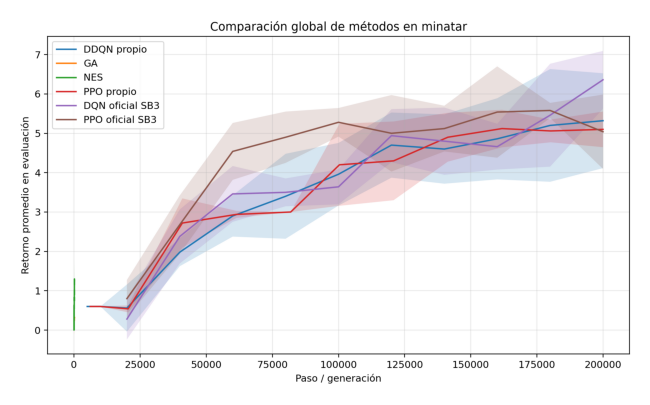

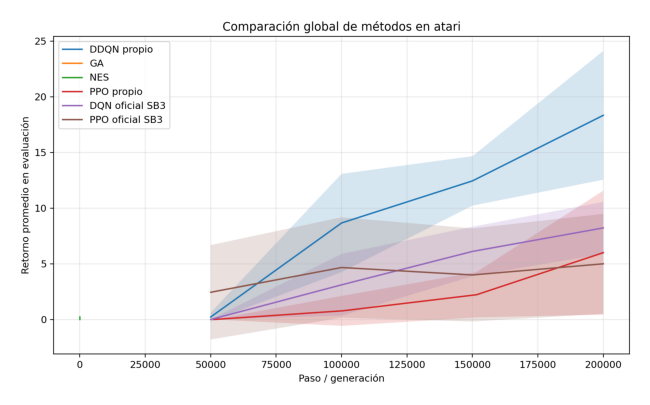

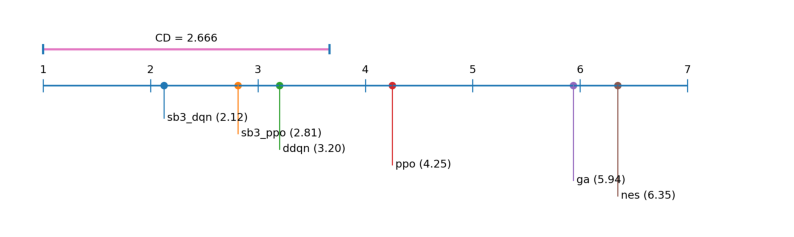

In [ ]:
for path in [
    "analysis_outputs/combined_curves_minatar.png",
    "analysis_outputs/combined_curves_atari.png",
    "analysis_outputs/critical_difference.png",
]:
    img = plt.imread(path)
    plt.figure(figsize=(10,5))
    plt.imshow(img)
    plt.axis("off")
    plt.show()



*Los recortes en las gráficas son debido al paso de evaluación que se ajustó en cada entrenamiento.

La última Figura corresponde a un diagrama de diferencias críticas, el cual resume la comparación global entre todos los métodos a partir de sus rangos promedio. En dicha gráfica, mientras más a la izquierda se ubique un método, mejor fue su desempeño relativo promedio, mientras que la barra superior marcada como CD indica la diferencia mínima entre rangos para considerar que dos métodos presentan una separación relevante en la comparación global; así, se observa que SB3 DQN, SB3 PPO y DDQN se agrupan entre los mejores métodos, mientras que GA y NES quedan claramente en las posiciones más bajas, confirmando las observaciones realizadas anteriormente.

----
Git backup:

In [ ]:
# !git status
# !git stash
# !git pull
# !git stash pop
# !git add .
# !git status
# !git commit -m "CompFinal: Se guardan los resultados de las comparaciones finales (globales) entre todos los modelos."
# !git push

# Conclusiones

A partir de los experimentos realizados en MinAtar Breakout y Atari Breakout, se compararon métodos basados en valor, gradiente de política y búsqueda evolutiva.

En términos generales:
- DDQN permitió reducir el sesgo de sobreestimación respecto a DQN vanilla.
- PPO mostró un entrenamiento más estable y competitivo.
- NES y GA resultaron funcionales, aunque con menor eficiencia muestral en comparación con DDQN y PPO.
- Las comparaciones estadísticas mediante Wilcoxon rank-sum permitieron identificar diferencias significativas entre algunos pares de métodos.
- El ranking promedio y el diagrama de diferencias críticas ofrecieron una visión global del comportamiento relativo de todos los algoritmos evaluados.